In [2]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from scipy.interpolate import griddata, interp1d
from mpl_toolkits.mplot3d import Axes3D
import csv
import pandas as pd
from scipy.interpolate import interp1d, UnivariateSpline, CubicSpline
from scipy.signal import savgol_filter

In [ ]:
# r
x_min = -10
x_max = 270
y_min = -7  
y_max = 7
z_min = -7
z_max = 7

In [ ]:
# d1
x_min = 0
x_max = 120
y_min = -4
y_max = 4
z_min = -4
z_max = 4

In [ ]:
# d2
x_min = 0
x_max = 80
y_min = -8
y_max = 8
z_min = -8
z_max = 8

In [3]:
plt.rcParams['font.family'] = 'Times New Roman'

In [ ]:
file_paths = glob.glob(r"D:\仿真\仿真数据\LD-PWB-FA-bridge\FA-PWB-Taper\*.txt", recursive=True)

# 初始化图像
plt.figure(figsize=(8, 5))

for file in file_paths:
    # 读取数据，跳过标题行
    data = np.loadtxt(file, delimiter=",", skiprows=3)
    wavelength = data[:, 0] * 1e9  # 转换为 nm
    t_forward = data[:, 1]
    loss = - np.log10(t_forward) * 10  # 转换为 dB
    # 自动生成图例标签（文件名最后一部分）
    label = os.path.basename(file).replace(".txt", "")
    
    # 绘图
    plt.plot(wavelength, loss, label=label)

# 图像美化
plt.xlabel("Wavelength (nm)", fontsize=14, fontweight='bold')
plt.ylabel("Loss (dB)", fontsize=14, fontweight='bold')
plt.title("second taper d2: Fundamental TE mode Loss vs. Wavelength", fontsize=16, fontweight='bold')
for spine in plt.gca().spines.values():
    spine.set_linewidth(2)
plt.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

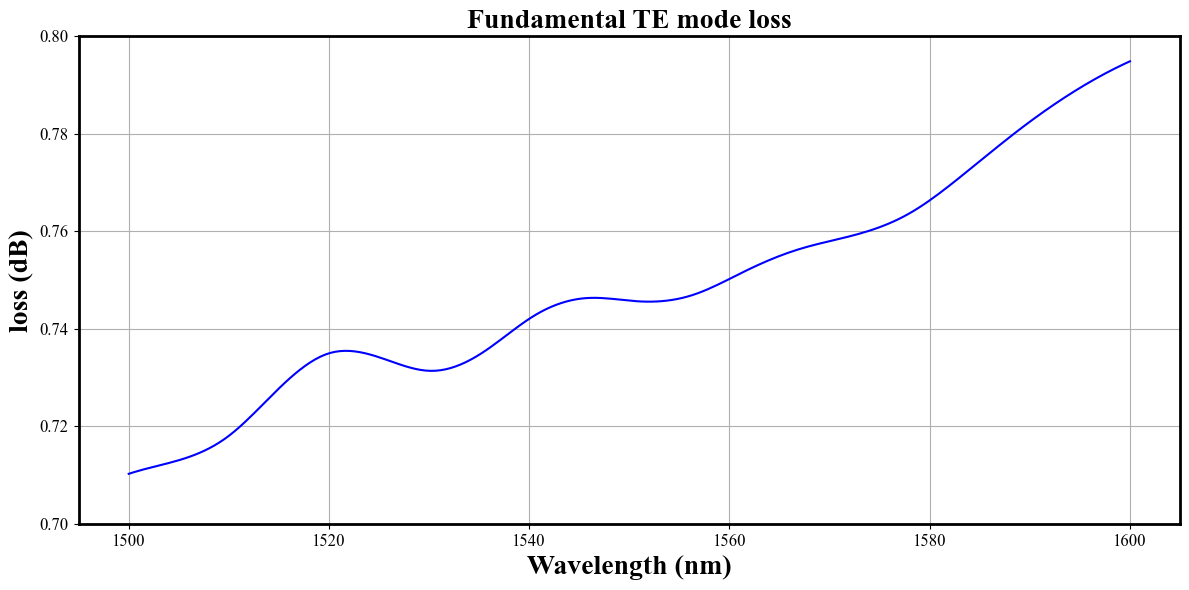

In [26]:
# 透射率 vs 波长
filename2 = r"D:\simulation\Simulation Project\simulation\LD-PWB-SMF\with ar 1.txt"
data = np.loadtxt(filename2, delimiter=',')
wavelengths = data[:, 0] * 1e9  # 转换为 nm
t_forward = data[:, 1]
loss = - np.log10(t_forward)*10
wavelengths_sorted = wavelengths[::-1]
loss_sorted = loss[::-1]
# 插值拟合
cs = CubicSpline(wavelengths_sorted, loss_sorted)
x_interp = np.linspace(wavelengths.min(), wavelengths.max(), 200)
y_cs = cs(x_interp)
# 绘图
plt.figure(figsize=(12, 6))
plt.tick_params(axis='both', labelsize=12) 
plt.plot(x_interp, y_cs, '-', color='blue', label='T_forward')
plt.xlabel('Wavelength (nm)', fontsize=20, fontweight='bold')
plt.ylabel('loss (dB)', fontsize=20, fontweight='bold')
plt.title('Fundamental TE mode loss', fontsize=20, fontweight='bold')
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_linewidth(2)
plt.xlim(wavelengths.min() - 5, wavelengths.max() + 5)
plt.ylim(0.7, 0.8)
plt.tight_layout()
plt.show()

In [ ]:
filename2 = r"C:\Users\22122\Desktop\专利\z=-9.txt"
data = np.loadtxt(filename2, delimiter=',')
wavelengths = data[:, 0]
t_forward = data[:, 1]
loss = - np.log10(t_forward)*10
plt.figure(figsize=(8, 5))
plt.scatter(wavelengths, loss, color='red', s=60, label='z=-9um, 1550nm')
plt.xlabel('X value (um)', fontsize=16, fontweight='bold')
plt.ylabel('Loss (dB)', fontsize=16, fontweight='bold')
plt.title('Loss', fontsize=16, fontweight='bold')
plt.grid(True)
plt.legend(fontsize=12)
for spine in plt.gca().spines.values():
    spine.set_linewidth(2)
plt.tight_layout()
plt.show()

In [ ]:
# XZ 截面
filename2 = r"D:\simulation\Simulation Project\results\fdtd export\transmission_monitor.txt"
Ex = np.loadtxt(filename2, delimiter=",")
x = np.linspace(x_min, x_max, Ex.shape[0])  
z = np.linspace(-6, 6, Ex.shape[1])  

# 绘图
plt.figure(figsize=(9, 3))
plt.pcolormesh(x, z, Ex.T, cmap='jet', shading='auto')
plt.xlabel("x (μm)")
plt.ylabel("z (μm)")
plt.title("Field")
plt.tight_layout()
plt.show()


In [ ]:
# output monitor
filename3 = r"D:\simulation\Simulation Project\results\fdtd export\output_monitor.txt"
Ex = np.loadtxt(filename3, delimiter=",")

# 可选：坐标轴
y = np.linspace(y_min, y_max, Ex.shape[0])  
z = np.linspace(z_min, z_max, Ex.shape[1])  

# 绘图
plt.figure(figsize=(6, 5))
plt.pcolormesh(y, z, Ex.T, cmap='jet', shading='auto')
plt.xlabel("y (μm)")
plt.ylabel("z (μm)")
plt.colorbar(label="E")
plt.title("E-YZ  lambda = 1550nm")
plt.tight_layout()
plt.show()


In [ ]:
# 读取数据文件
with open("D:/Wechat Files/WeChat Files/wxid_umtzlz2f1fad22/FileStorage/File/2025-06/Wave Intensity.txt", 'r') as f:
    lines = f.readlines()

# 解析数据
triangles = []
for i in range(2, len(lines)):  # 跳过前两行
    line = lines[i].strip().split()
    if len(line) == 4:
        x, y, z, intensity = map(float, line)
        triangles.append([x, y, z, intensity])

triangles = np.array(triangles).reshape(-1, 3, 4)

# 去重顶点数据
unique_points = {}
for tri in triangles:
    for vertex in tri:
        key = (vertex[0], vertex[1], vertex[2])  # (x, y, z) 作为键
        if key not in unique_points or unique_points[key][3] < vertex[3]:
            unique_points[key] = vertex  # 保留最大强度值（可根据需求调整）

# 转换为数组
points = np.array(list(unique_points.values()))
num_vertices = len(points)

# 获取 x, y 范围
x_coords = points[:, 0]
y_coords = points[:, 1]
x_min, x_max = min(x_coords), max(x_coords)
y_min, y_max = min(y_coords), max(y_coords)
symmetry_center = 0.0  # 新对称轴

# 创建完整网格（考虑对称性）
x_grid = np.linspace(-x_max, x_max, 200)  # 完整 x 范围 (-x_max 到 x_max)
y_grid = np.linspace(y_min, y_max, 200)
X, Y = np.meshgrid(x_grid, y_grid)
Z = np.zeros_like(X, dtype=float)

# 提取插值点和值
interp_points = points[:, [0, 1]]  # (x, y)
interp_values = points[:, 3]       # intensity

# 插值原始部分
Z_original = griddata(interp_points, interp_values, (X, Y), method='linear', fill_value=0)

# 镜像对称部分
mirrored_points = np.copy(interp_points)
mirrored_points[:, 0] = -mirrored_points[:, 0]  # 以 x=0 镜像
Z_mirrored = griddata(mirrored_points, interp_values, (X, Y), method='linear', fill_value=0)

# 组合原始和镜像数据
Z = Z_original + Z_mirrored

# 绘制热图
plt.figure(figsize=(8, 6))
plt.pcolormesh(X, Y, Z, shading='auto', cmap='jet', vmin=0, vmax=Z.max())
plt.colorbar(label='Intensity')
plt.xlabel('X (um)')
plt.ylabel('Y (um)')
plt.title('Intensity')
plt.xlim(-4, 4)
plt.ylim(0, 3)
plt.show()
# 打印范围以调试
print(f"X range: {x_min} to {x_max}")
print(f"Y range: {y_min} to {y_max}")
print(f"Intensity range: {Z.min()} to {Z.max()}")
print(f"Number of unique vertices: {num_vertices}")

In [ ]:
root_dir = r"D:\仿真\仿真数据\LD-PWB-FA-bridge\LD-PWB-Taper"  
results = []

for d2_folder in glob.glob(os.path.join(root_dir, "step2*")):
    d2 = float(os.path.basename(d2_folder).split("_")[1])
    for txt_file in glob.glob(os.path.join(d2_folder, "*.txt")):
        d1 = float(os.path.basename(txt_file).replace(".txt", ""))
        data = np.loadtxt(txt_file, delimiter=",", skiprows=3)
        wavelength = data[:, 0] * 1e9  # nm
        t_forward = data[:, 1]
        idx = np.argmin(np.abs(wavelength - 1550))
        t_1550= - np.log10(t_forward[idx]) * 10 
        results.append({"d2": d2, "d1": d1, "t_1550": t_1550})

df = pd.DataFrame(results)

d1 = df['d1'].values
d2 = df['d2'].values
T = df['t_1550'].values

# 生成更细致的网格
d1_lin = np.linspace(d1.min(), d1.max(), 100)
d2_lin = np.linspace(d2.min(), d2.max(), 100)
D2_grid, D1_grid = np.meshgrid(d2_lin, d1_lin)
T_grid = griddata((d2, d1), T, (D2_grid, D1_grid), method='cubic')
# 生成透射率矩阵
pivot = df.pivot(index="d1", columns="d2", values="t_1550")
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 取出d1, d2, t_1550的网格
d1_vals = pivot.index.values
d2_vals = pivot.columns.values
D2, D1 = np.meshgrid(d2_vals, d1_vals)
T = pivot.values
surf = ax.plot_surface(D2_grid, D1_grid, T_grid, cmap='jet_r', edgecolor='none')
#surf = ax.plot_trisurf(D2.ravel(), D1.ravel(), T.ravel(), cmap='jet_r', edgecolor='none')
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.15)
ax.set_xlabel('d2(um)')
ax.set_ylabel('d1(um)')
ax.set_xlim(1.15, 0.65)
ax.set_ylim(1.9, 0.7)
ax.set_zlabel('TE ModeLoss (@1550nm)')
ax.set_title('Transmission $\eta_1$ at 1550nm')
ax.set_zlim(1.6, 1.0) 
plt.show()

In [ ]:
root_dir = r"D:\仿真\仿真数据\LD-PWB-FA-bridge\LD-PWB-Taper"  
results = []

for d2_folder in glob.glob(os.path.join(root_dir, "step2*")):
    d2 = float(os.path.basename(d2_folder).split("_")[1])
    for txt_file in glob.glob(os.path.join(d2_folder, "*.txt")):
        d1 = float(os.path.basename(txt_file).replace(".txt", ""))
        data = np.loadtxt(txt_file, delimiter=",", skiprows=3)
        wavelength = data[:, 0] * 1e9  # nm
        t_forward = data[:, 1]
        idx = np.argmin(np.abs(wavelength - 1540))
        t_1550= - np.log10(t_forward[idx]) * 10 
        results.append({"d2": d2, "d1": d1, "t_1550": t_1550})

df = pd.DataFrame(results)

d1 = df['d1'].values
d2 = df['d2'].values
T = df['t_1550'].values

# 生成更细致的网格
d1_lin = np.linspace(d1.min(), d1.max(), 100)
d2_lin = np.linspace(d2.min(), d2.max(), 100)
D2_grid, D1_grid = np.meshgrid(d2_lin, d1_lin)
T_grid = griddata((d2, d1), T, (D2_grid, D1_grid), method='cubic')
# 生成透射率矩阵
pivot = df.pivot(index="d1", columns="d2", values="t_1550")
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 取出d1, d2, t_1550的网格
d1_vals = pivot.index.values
d2_vals = pivot.columns.values
D2, D1 = np.meshgrid(d2_vals, d1_vals)
T = pivot.values
surf = ax.plot_surface(D2_grid, D1_grid, T_grid, cmap='jet_r', edgecolor='none')
#surf = ax.plot_trisurf(D2.ravel(), D1.ravel(), T.ravel(), cmap='jet_r', edgecolor='none')
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.15)
ax.set_xlabel('d2(um)')
ax.set_ylabel('d1(um)')
ax.set_xlim(1.15, 0.65)
ax.set_ylim(1.9, 0.7)
ax.set_zlabel('TE ModeLoss (@1540nm)')
ax.set_title('Transmission $\eta_1$ at 1540nm')
ax.set_zlim(1.7, 1.0) 
plt.show()

In [20]:
root_dir = r"D:\仿真\仿真数据\LD-PWB-FA-bridge\LD-PWB-Taper"  
results = []

for d2_folder in glob.glob(os.path.join(root_dir, "step2*")):
    d2 = float(os.path.basename(d2_folder).split("_")[1])
    for txt_file in glob.glob(os.path.join(d2_folder, "*.txt")):
        d1 = float(os.path.basename(txt_file).replace(".txt", ""))
        data = np.loadtxt(txt_file, delimiter=",", skiprows=3)
        wavelength = data[:, 0] * 1e9  # nm
        t_forward = data[:, 1]
        idx = np.argmin(np.abs(wavelength - 1560))
        t_1550= - np.log10(t_forward[idx]) * 10 
        results.append({"d2": d2, "d1": d1, "t_1550": t_1550})

df = pd.DataFrame(results)

d1 = df['d1'].values
d2 = df['d2'].values
T = df['t_1550'].values

# 生成更细致的网格
d1_lin = np.linspace(d1.min(), d1.max(), 100)
d2_lin = np.linspace(d2.min(), d2.max(), 100)
D2_grid, D1_grid = np.meshgrid(d2_lin, d1_lin)
T_grid = griddata((d2, d1), T, (D2_grid, D1_grid), method='cubic')
# 生成透射率矩阵
pivot = df.pivot(index="d1", columns="d2", values="t_1550")
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 取出d1, d2, t_1550的网格
d1_vals = pivot.index.values
d2_vals = pivot.columns.values
D2, D1 = np.meshgrid(d2_vals, d1_vals)
T = pivot.values
surf = ax.plot_surface(D2_grid, D1_grid, T_grid, cmap='jet_r', edgecolor='none')
#surf = ax.plot_trisurf(D2.ravel(), D1.ravel(), T.ravel(), cmap='jet_r', edgecolor='none')
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.15)
ax.set_xlabel('d2(um)')
ax.set_ylabel('d1(um)')
ax.set_xlim(1.15, 0.65)
ax.set_ylim(1.9, 0.7)
ax.set_zlabel('TE ModeLoss (@1560nm)')
ax.set_title('Transmission $\eta_1$ at 1560nm')
ax.set_zlim(1.6, 1.0) 
plt.show()

KeyError: 'd1'

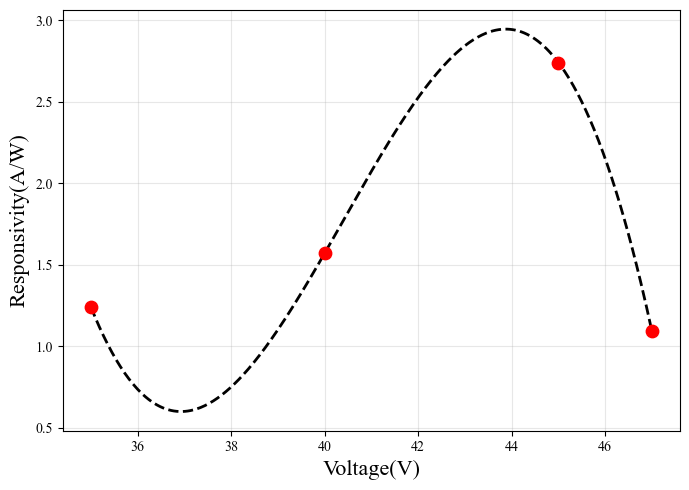

In [5]:
volt = np.array([35, 40, 45, 47])
eff  = np.array([1.24, 1.57, 2.74, 1.09])

# 保证按电压升序用于插值
order = np.argsort(volt)
volt_s = volt[order]; eff_s = eff[order]

# 三次样条平滑插值
cs = CubicSpline(volt_s, eff_s)
x_fit = np.linspace(volt_s.min(), volt_s.max(), 400)
y_fit = cs(x_fit)

plt.figure(figsize=(7,5))
plt.scatter(volt, eff, color='red', s=80, zorder=5)
plt.plot(x_fit, y_fit, linestyle='--', color='black', linewidth=2, zorder=3)
plt.xlabel('Voltage(V)', fontsize=16)
plt.ylabel('Responsivity(A/W)', fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

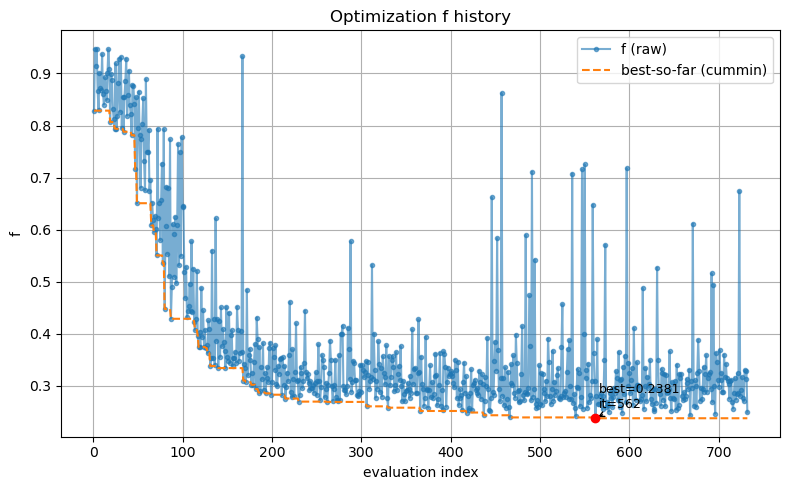

Saved plot to: D:\xwechat_files\wxid_umtzlz2f1fad22_9bf9\msg\file\2025-11\bend_f_history.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path(r"D:\xwechat_files\wxid_umtzlz2f1fad22_9bf9\msg\file\2025-11\bend_optimization_log.csv")
df = pd.read_csv(csv_path)

# 尽量找到 f 列（容错）
if "f" in df.columns:
    f = df["f"].astype(float).values
else:
    f = df.iloc[:, -1].astype(float).values

it = np.arange(1, len(f) + 1)
mavg = pd.Series(f).rolling(window=5, min_periods=1).mean().values
best_so_far = np.minimum.accumulate(f)
best_idx = int(np.argmin(f))
best_val = float(f[best_idx])

plt.figure(figsize=(8, 5))
plt.plot(it, f, '.-', alpha=0.6, label='f (raw)')
# plt.plot(it, mavg, '-', linewidth=2, label='moving avg (window=5)')
plt.plot(it, best_so_far, '--', linewidth=1.5, label='best-so-far (cummin)')
plt.scatter([best_idx+1], [best_val], color='red', zorder=10)
plt.annotate(f"best={best_val:.4f}\nit={best_idx+1}", (best_idx+1, best_val),
             xytext=(best_idx+5, best_val+0.02),
             arrowprops=dict(arrowstyle="->"), fontsize=9)
plt.xlabel("evaluation index")
plt.ylabel("f")
plt.title("Optimization f history")
plt.grid(True)
plt.legend()
out = csv_path.parent / "bend_f_history.png"
plt.tight_layout()
# plt.savefig(out, dpi=200)
plt.show()
print(f"Saved plot to: {out}")